<a href="https://www.kaggle.com/code/mrafraim/predictive-supply-chain-analytics?scriptVersionId=300431453" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predictive Supply Chain Analytics: Revenue and Risk Forecasting

# 1. Project Overview

### Objective

The objective of this project is to develop a predictive and diagnostic analytical framework for evaluating revenue performance and operational risk within the supply chain of a **Fashion & Beauty startup specializing in makeup products**.

This project focuses on:

* Identifying key drivers of revenue generation across products and SKUs.
* Quantifying operational risks such as high defect rates, extended lead times, and cost volatility.
* Building predictive models to forecast revenue and assess supply chain risk exposure.
* Translating analytical findings into strategic actions for cost optimization and performance stability.

The core business question addressed:

> Which operational factors most strongly influence revenue performance, and how can supply chain risks be predicted and mitigated proactively?

### Domain

Supply Chain Analytics
Industry: Fashion & Beauty (Makeup Products)

### Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Plotly
* Scikit-learn
* SciPy (for statistical validation)


### Dataset Source

[Kaggle Open Source Dataset](https://www.kaggle.com/datasets/harshsingh2209/supply-chain-analysis)

### Dataset Size

Records – 100 | Features – 24


# 2. Data Understanding

## 2.1 Dataset Overview

The dataset contains **100 records** and **24 features**, covering product-level supply chain performance across procurement, production, logistics, quality control, and financial outcomes.


| Feature                 | Description                                                                  |
| ----------------------- | ---------------------------------------------------------------------------- |
| Product type            | Category of the makeup product (e.g., lipstick, foundation, skincare)        |
| SKU                     | Stock Keeping Unit - Unique stock keeping unit identifier                    |
| Price                   | Selling price per unit                                                       |
| Availability            | Availability status/units available for sale                                 |
| Number of products sold | Total units sold                                                             |
| Revenue generated       | Total revenue from the product                                               |
| Customer demographics   | Customer segment category                                                    |
| Stock levels            | Current inventory level                                                      |
| Lead times              | Procurement lead time from supplier                                          |
| Order quantities        | Quantity ordered from supplier                                               |
| Shipping times          | Time required for delivery                                                   |
| Shipping carriers       | Logistics provider handling shipment                                         |
| Shipping costs          | Cost incurred for shipping                                                   |
| Supplier name           | Name of the supplier                                                         |
| Location                | Geographic location of supplier or warehouse                                 |
| Lead time               | Additional recorded lead time metric (possible duplication; to be validated) |
| Production volumes      | Units produced                                                               |
| Manufacturing lead time | Time required for manufacturing                                              |
| Manufacturing costs     | Cost of production                                                           |
| Inspection results      | Quality inspection outcome (Pass/Fail/Conditional)                           |
| Defect rates            | Percentage of defective units                                                |
| Transportation modes    | Mode of transport (Air, Sea, Road, etc.)                                     |
| Routes                  | Shipping route identifier                                                    |
| Costs                   | Aggregated or operational cost metric                                        |

In [1]:
#Import Necessary Libraries
import pandas as pd # Pandas is used for data manipulation and analysis
import numpy as np # Numpy is used for numerical operations
import matplotlib.pyplot as plt # Matplotlib is used for creating static, animated, and interactive visualizations
import seaborn as sns # Seaborn is used for making statistical graphics
from scipy import stats # Scipy is used for scientific and technical computing

# Warnings is used to manage warning messages
import warnings
warnings.filterwarnings('ignore')

# Plotly is used for interactive visualizations
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# Confirming the imports
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/supply-chain-analysis/supply_chain_data.csv')

# Set option to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the dataframe
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

## 2.2 Initial Observations

### 1. Missing Values

In [4]:
# Check for missing values
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

No missing values are present in any of the 24 features. The dataset is complete for all records.

### 2. Duplicate Values

In [5]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

No duplicate records detected. Each row represents a unique SKU and product entry.

### 3. Target Variable Distribution

Since the predictive focus is revenue forecasting, the target variable is Revenue generated (continuous).

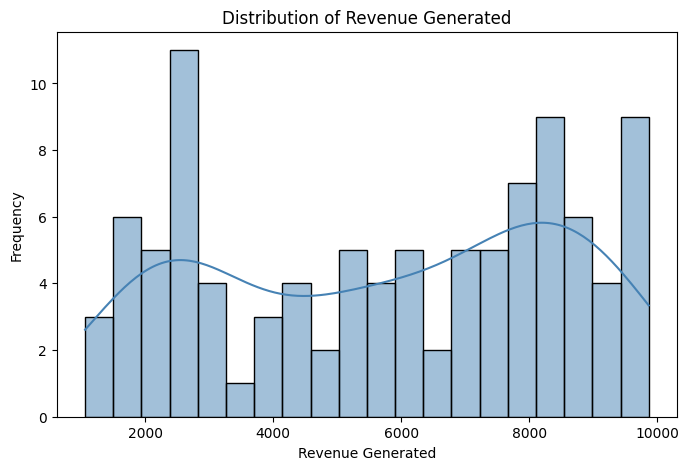

In [6]:
# Check target variable distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Revenue generated'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of Revenue Generated")
plt.xlabel("Revenue Generated")
plt.ylabel("Frequency")
plt.show()

The data follows a bimodal distribution which indicates two main groups: most sales are either small or large. There is a big gap in the middle, meaning customers rarely spend a medium amount.

### 4. Structural Observations

* **Potential Feature Duplication:**

  * `Lead times` and `Lead time` may overlap; this will need clarification during data preparation.
* **Mixed Units Across Cost Metrics:**

  * `Manufacturing costs`, `Shipping costs`, and `Costs` may overlap or aggregate differently. Requires normalization for modeling.
* **Categorical Diversity:**

  * `Product type`, `Customer demographics`, `Shipping carriers`, `Supplier name`, `Transportation modes` appear to have multiple levels, encoding will be required.
* **Operational Features for Risk Modeling:**

  * `Defect rates`, `Inspection results`, `Lead times`, and `Shipping times` are potential predictors for risk exposure.


# 3. Data Preparation

<p style="text-align:center; color:red; font-size:18px;"> To be continue</p>

---

<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
